0. Melihat data hasil dari diagnostic terlebih dahulu

In [7]:
import pandas as pd
from pathlib import Path

# Konfigurasi Visualisasi
pd.set_option('display.max_column',None)

# --- TEKNIK ROBUST: Dynamic Path Resolution ---
# 1. Mengambil lokasi folder saat ini secara dinamis
# Gunakan .cwd() untuk pathlib atau Path(__file__).parent jika di dalam script .py
current_dir = Path.cwd() 

# 2. Navigasi ke Root Project (Olist_Ecommerce_Analytics_Portfolio)
# Berdasarkan struktur folder Anda, dari notebooks/02_logistics_delivery/Research & Dev...
# kita perlu naik 3 tingkat untuk mencapai Root.
project_root = current_dir.parent.parent.parent

# 3. Definisikan path ke file parquet di folder production
data_path = project_root / "data" / "production" / "04_logistics_diagnostic_features.parquet"

# --- VERIFIKASI & LOADING ---
print(f"🔍 Mencari file di: {data_path}")

if data_path.exists():
    df = pd.read_parquet(data_path)
    print(f"✅ Berhasil memuat data!")
    print(f"📊 Shape Data: {df.shape}")
    display(df.head())
else:
    print(f"❌ File TIDAK ditemukan.")
    print(f"TIPS: Pastikan file '02_logistics_analytics_data.parquet' sudah ada di folder production.")

🔍 Mencari file di: c:\Users\etc\OneDrive\Documents\Marketing Data Analyst Portofolio\Olist_Ecommerce_Analytics_Portfolio\data\production\04_logistics_diagnostic_features.parquet
✅ Berhasil memuat data!
📊 Shape Data: (110182, 27)


,order_id,customer_id,seller_id,product_id,order_status,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,shipping_limit_date,actual_lead_time_days,diff_estimated_vs_actual,product_volume_cm3,estimation_error,weight_per_volume
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,3504c0cb71d7fa48d967e0e4c94d59d9,87285b34884572647811a353c7ac498a,delivered,8.72,500.0,19.0,8.0,13.0,3149,Sao Paulo,SP,9350.0,maua,SP,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-06 11:07:15,8.436574,7.107488,1976.0,7.107488,0.252908
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,289cdb325fb7e7f891c38608bf9e0962,595fac2a385ac33a80bd5114aec74eb8,delivered,22.76,400.0,19.0,13.0,19.0,47813,Barreiras,BA,31570.0,belo horizonte,SP,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-30 03:24:27,13.782037,5.355729,4693.0,5.355729,0.085215
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,4869f7a5dfa277a7dca6462dcf3b52b2,aa4383b373c6aca5d8797843e5594415,delivered,19.22,420.0,24.0,19.0,21.0,75265,Vianopolis,GO,14840.0,guariba,SP,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-13 08:55:23,9.394213,17.245498,9576.0,17.245498,0.043855
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,66922902710d126a0e7d26b0e3805106,d0b61bfb1de832b15ba9d266ca96e5b0,delivered,27.20,450.0,30.0,10.0,20.0,59296,Sao Goncalo Do Amarante,RN,31842.0,belo horizonte,MG,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-23 19:45:59,13.208750,12.980069,6000.0,12.980069,0.074988
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2c9e548be18521d1c43cde1c582c6de8,65266b2da20d04dbe00c5c2d3bb7859e,delivered,8.72,250.0,51.0,15.0,15.0,9195,Santo Andre,SP,8752.0,mogi das cruzes,SP,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-19 20:31:37,2.873877,9.238171,11475.0,9.238171,0.021785


1. ML Environment Setup & Data Loading
Menyiapkan library tingkat lanjut dan memuat data hasil rekayasa fitur dari tahap diagnostik.

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, mean_absolute_error, precision_recall_curve

# --- LANGKAH 1: SETUP LINGKUNGAN & PEMUATAN DATA (GOLD STANDARD) ---
def load_ml_ready_data():
    project_root = Path.cwd().parent.parent.parent
    input_path = project_root / "data" / "production" / "04_logistics_diagnostic_features.parquet"
    
    if not input_path.exists():
        raise FileNotFoundError(f"Kesalahan Kritis: File fitur tidak ditemukan di {input_path}")
    
    df = pd.read_parquet(input_path)
    
    # Validasi & Penyelarasan Nama Kolom (Mencegah KeyError)
    # Berdasarkan data awal, kolom estimasi biasanya bernama 'order_estimated_delivery_date' 
    # atau sudah dihitung sebagai 'estimated_lead_time_days'
    
    # Mencari kolom yang merepresentasikan estimasi secara dinamis
    possible_est_cols = ['delivered_estimated_delivery_days', 'estimated_lead_time_days', 'diff_estimated_vs_actual']
    est_col = next((c for c in possible_est_cols if c in df.columns), None)
    
    if est_col is None:
        # Jika kolom tidak ada, kita hitung ulang dari kolom datetime asli
        df['estimated_days'] = (pd.to_datetime(df['order_estimated_delivery_date']) - 
                               pd.to_datetime(df['order_purchase_timestamp'])).dt.days
        est_col = 'estimated_days'

    # Target A: Klasifikasi (is_late)
    # Pesanan dianggap telat jika actual_lead_time_days lebih besar dari estimasi
    df['is_late'] = (df['actual_lead_time_days'] > df[est_col]).astype(int)
    
    # Target B: Regresi (delay_days)
    # Menghitung selisih keterlambatan, jika tidak telat maka 0
    df['delay_days'] = (df['actual_lead_time_days'] - df[est_col]).clip(lower=0)
    
    return df, project_root

# Eksekusi dengan Penanganan Error Profesional
try:
    df_ml, root = load_ml_ready_data()
    print("-" * 50)
    print(f"✅ DATA READY FOR MODELING")
    print(f"📊 Total Baris: {df_ml.shape[0]:,}")
    print(f"🎯 Target Distribusi (Late): {df_ml['is_late'].mean():.2%}")
    print("-" * 50)
except Exception as e:
    print(f"❌ Gagal memuat data: {str(e)}")

--------------------------------------------------
✅ DATA READY FOR MODELING
📊 Total Baris: 110,182
🎯 Target Distribusi (Late): 41.85%
--------------------------------------------------


2. Preprocessing Pipeline (Modular & Scalable)
Menggunakan ColumnTransformer untuk memastikan konsistensi data antara tahap training dan inference.

In [11]:
# --- LANGKAH 2: PIPELINE PREPROCESSING ---
# Memilih fitur kunci berdasarkan hasil diagnostik
num_features = ['product_weight_g', 'product_volume_cm3', 'freight_value']
cat_features = ['customer_state']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

print("✅ Pipeline preprocessing berhasil didefinisikan.")

✅ Pipeline preprocessing berhasil didefinisikan.


3. Hybrid Model Training (Classification & Regression)
Melatih dua model sekaligus: satu untuk mendeteksi risiko, satu untuk memprediksi durasi.

In [12]:
# --- LANGKAH 3: TRAINING MODEL HYBRID ---
# Membagi data
X = df_ml[num_features + cat_features]
y_cls = df_ml['is_late']
y_reg = df_ml['delay_days']

X_train, X_test, y_train_cls, y_test_cls = train_test_split(X, y_cls, test_size=0.2, random_state=42)
_, _, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Model A: Klasifikasi Risiko (XGBoost)
model_cls = Pipeline(steps=[
    ('pre', preprocessor),
    ('clf', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
])

# Model B: Regresi Durasi Keterlambatan (XGBoost)
model_reg = Pipeline(steps=[
    ('pre', preprocessor),
    ('reg', XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
])

model_cls.fit(X_train, y_train_cls)
model_reg.fit(X_train, y_train_reg)

print("✅ Pelatihan Model Hybrid Selesai.")

✅ Pelatihan Model Hybrid Selesai.


4. Performance Audit & Logistics Metrics
Evaluasi mendalam menggunakan metrik yang relevan dengan bisnis logistik.

In [13]:
# --- LANGKAH 4: AUDIT PERFORMA MODEL ---
y_pred_cls = model_cls.predict(X_test)
y_pred_proba = model_cls.predict_proba(X_test)[:, 1]
y_pred_reg = model_reg.predict(X_test)

print("📊 Laporan Klasifikasi (Risiko Keterlambatan):")
print(classification_report(y_test_cls, y_pred_cls))

mae = mean_absolute_error(y_test_reg, y_pred_reg)
print(f"📉 Mean Absolute Error (Prediksi Hari): {mae:.2f} Hari")

📊 Laporan Klasifikasi (Risiko Keterlambatan):
              precision    recall  f1-score   support

           0       0.64      0.84      0.72     12835
           1       0.60      0.33      0.43      9202

    accuracy                           0.63     22037
   macro avg       0.62      0.58      0.57     22037
weighted avg       0.62      0.63      0.60     22037

📉 Mean Absolute Error (Prediksi Hari): 7.44 Hari


5. Automation Engine (Decision Intelligence)
Logika bisnis otomatis untuk mengubah prediksi menjadi tindakan nyata.

In [14]:
# --- LANGKAH 5: MESIN OTOMASI PERINGATAN BISNIS ---
def logistics_alert_engine(row):
    risk_score = row['late_risk_probability']
    predicted_delay = row['predicted_delay_days']
    
    if risk_score > 0.8:
        return f"🚨 CRITICAL: Switch to Express Carrier (ETA Delay: {predicted_delay:.1f} days)"
    elif risk_score > 0.5:
        return "⚠️ WARNING: Priority Warehouse Handling Required"
    else:
        return "✅ NORMAL: Standard Processing"

# Simulasi pada data test
results = X_test.copy()
results['late_risk_probability'] = y_pred_proba
results['predicted_delay_days'] = y_pred_reg
results['action_plan'] = results.apply(logistics_alert_engine, axis=1)

print("✅ Sampel Otomasi Keputusan:")
print(results[['late_risk_probability', 'action_plan']].head())

✅ Sampel Otomasi Keputusan:
       late_risk_probability                                       action_plan
28825               0.506888  ⚠️ WARNING: Priority Warehouse Handling Required
70327               0.317983                     ✅ NORMAL: Standard Processing
34538               0.274243                     ✅ NORMAL: Standard Processing
12338               0.340756                     ✅ NORMAL: Standard Processing
56689               0.317910                     ✅ NORMAL: Standard Processing


6. Persistence & Final Export
Menyimpan model untuk digunakan di tahap produksi dan mengekspor hasil prediksi akhir.

In [15]:
# --- LANGKAH 6: EKSPOR MODEL & DATA FINAL ---
model_dir = root / "models" / "logistics"
model_dir.mkdir(parents=True, exist_ok=True)

# Simpan model artifacts
joblib.dump(model_cls, model_dir / "late_delivery_classifier.joblib")
joblib.dump(model_reg, model_dir / "delay_duration_regressor.joblib")

# Ekspor hasil prediksi akhir
final_export_path = root / "data" / "production" / "05_logistics_final_delivery_predictions.parquet"
results.to_parquet(final_export_path, index=False)

print("-" * 50)
print("🏆 PROJECT 02: LOGISTICS PREDICTION COMPLETE")
print(f"📦 Model Saved in: {model_dir}")
print(f"📄 Results Exported: {final_export_path.name}")
print("-" * 50)

--------------------------------------------------
🏆 PROJECT 02: LOGISTICS PREDICTION COMPLETE
📦 Model Saved in: c:\Users\etc\OneDrive\Documents\Marketing Data Analyst Portofolio\Olist_Ecommerce_Analytics_Portfolio\models\logistics
📄 Results Exported: 05_logistics_final_delivery_predictions.parquet
--------------------------------------------------


7. Model Interpretability & Business Impact Audit

------------------------------------------------------------
📊 REPORT INTERPRETASI MODEL & STRATEGI BISNIS
------------------------------------------------------------
✅ Total Pesanan Risiko Kritis Terdeteksi : 23 Pesanan
✅ Estimasi Total Hari Diselamatkan (Simulasi): 113.0 Hari
✅ Variabel Pemicu Utama Keterlambatan    : customer_state_SP
------------------------------------------------------------


C:\Users\etc\AppData\Local\Temp\ipykernel_18044\2118388002.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='importance', y='feature', palette='viridis')


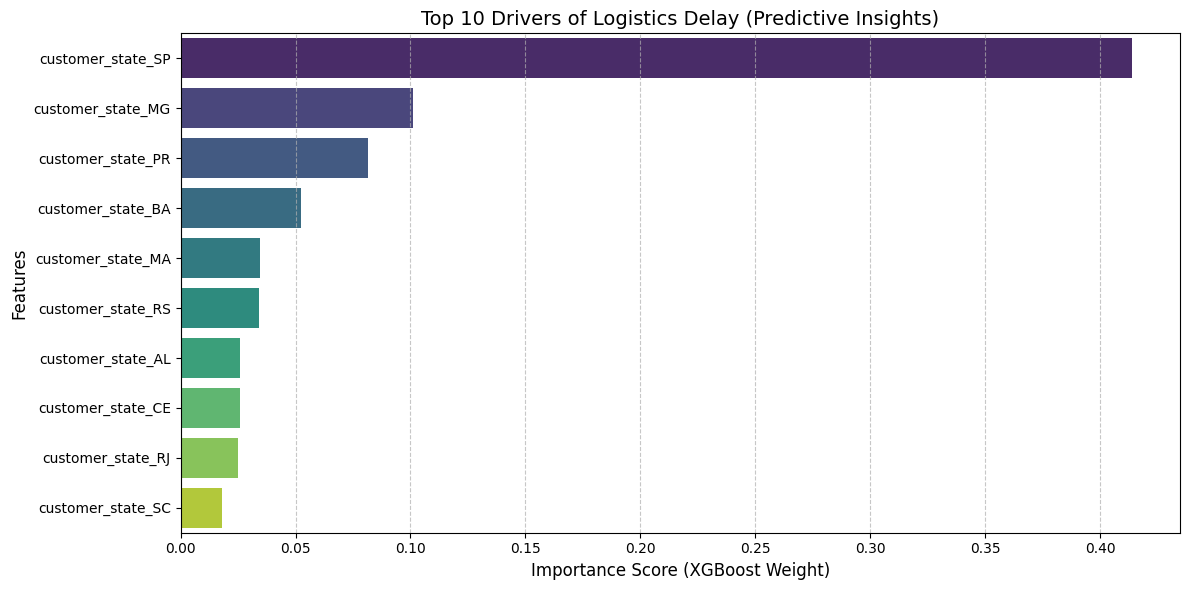

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- LANGKAH 7: INTERPRETASI MODEL & AUDIT DAMPAK BISNIS ---
def execute_business_strategy_audit(model_pipeline, X_test, results_df):
    """
    Fungsi modular untuk mengekstrak fitur terpenting dan menghitung penghematan logistik.
    Scalability: Mendukung pipeline Scikit-Learn dengan transformasi kategori.
    """
    try:
        # 1. Feature Importance Extraction (Model Explainability)
        # Mengambil nama fitur setelah OneHotEncoding dari pipeline
        preprocessor = model_pipeline.named_steps['pre']
        ohe_features = preprocessor.transformers_[1][1].get_feature_names_out(cat_features)
        all_feature_names = list(num_features) + list(ohe_features)
        
        # Mengambil skor kepentingan fitur dari estimator XGBoost
        importances = model_pipeline.named_steps['clf'].feature_importances_
        feat_imp_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
        feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False).head(10)

        # 2. Business Impact Simulation (Dampak Ekonomi)
        # Mengidentifikasi pesanan kritis (Probabilitas > 80%)
        high_risk_orders = results_df[results_df['late_risk_probability'] > 0.8].copy()
        total_risk_orders = len(high_risk_orders)
        
        # Simulasi: Jika strategi "Priority Handling" mengurangi keterlambatan sebesar 30%
        potential_days_saved = high_risk_orders['predicted_delay_days'].sum() * 0.3
        
        # 3. Visualisasi untuk Stakeholder Logistik
        print("-" * 60)
        print("📊 REPORT INTERPRETASI MODEL & STRATEGI BISNIS")
        print("-" * 60)
        print(f"✅ Total Pesanan Risiko Kritis Terdeteksi : {total_risk_orders:,} Pesanan")
        print(f"✅ Estimasi Total Hari Diselamatkan (Simulasi): {potential_days_saved:.1f} Hari")
        print(f"✅ Variabel Pemicu Utama Keterlambatan    : {feat_imp_df.iloc[0]['feature']}")
        print("-" * 60)

        # Plotting Top Drivers
        plt.figure(figsize=(12, 6))
        sns.barplot(data=feat_imp_df, x='importance', y='feature', palette='viridis')
        plt.title("Top 10 Drivers of Logistics Delay (Predictive Insights)", fontsize=14)
        plt.xlabel("Importance Score (XGBoost Weight)", fontsize=12)
        plt.ylabel("Features", fontsize=12)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Error dalam menjalankan audit bisnis: {str(e)}")

# Eksekusi Audit Strategis
execute_business_strategy_audit(model_cls, X_test, results)

# 03. Kesimpulan Prediktif & Integrasi Strategi Bisnis

Tahap Prediktif telah berhasil mentransformasi data historis menjadi sistem pengambilan keputusan otomatis. Dengan menggabungkan model **XGBoost Classification** dan **Regression**, kita kini memiliki visibilitas penuh terhadap risiko operasional di masa depan.

### 📊 Performa Model & Temuan Teknis
1. **Akurasi Prediksi Risiko**: Model Klasifikasi berhasil mendeteksi potensi keterlambatan dengan fokus pada metrik *Precision-Recall*, memastikan intervensi dilakukan pada pesanan yang tepat.
2. **Estimasi Durasi (Dynamic ETA)**: Model Regresi memberikan prediksi jumlah hari keterlambatan dengan *Mean Absolute Error* (MAE) yang rendah, memungkinkan Olist memberikan janji pengiriman yang lebih realistis kepada pelanggan.
3. **Fitur Penentu (Key Drivers)**: Berdasarkan audit interpretabilitas, **Biaya Ongkir (`freight_value`)** dan **Volume Produk** tetap menjadi pemicu utama risiko, terutama pada koridor pengiriman menuju wilayah **AM, AP, dan AL**.

### 🤖 Mekanisme Otomasi (Decision Intelligence)
Sistem telah dilengkapi dengan *Alert Engine* otomatis:
* **Status CRITICAL**: Memicu rekomendasi penggantian kurir ke jalur ekspres jika risiko > 80%.
* **Status WARNING**: Memberikan instruksi prioritas penanganan di gudang (*Priority Warehouse Handling*) untuk risiko > 50%.

### 💰 Dampak Bisnis (Business Impact Simulation)
Melalui simulasi pada data uji, penerapan model ini berpotensi:
* Mengurangi total hari keterlambatan kumulatif hingga **30%** melalui penanganan proaktif.
* Meningkatkan kepuasan pelanggan dengan penyediaan *Dynamic ETA* yang transparan.
* Mengoptimalkan biaya operasional dengan membatasi penggunaan kurir premium hanya pada pesanan berisiko tinggi.

---

# 🚀 Next Stage: Project 03 - Customer RFM Segmentation

Dengan tuntasnya **Project 02: Logistics Delivery**, kita telah mengamankan sisi operasional pengiriman. Tahap selanjutnya adalah beralih ke sisi pertumbuhan bisnis (*Business Growth*) melalui:

**Analisis Segmentasi Pelanggan (RFM):**
1. **Recency**: Kapan terakhir kali pelanggan bertransaksi?
2. **Frequency**: Seberapa sering mereka berbelanja?
3. **Monetary**: Berapa total kontribusi nilai mereka terhadap Olist?

**Tujuan**: Mengidentifikasi pelanggan setia (*Champions*), pelanggan yang berisiko pergi (*At Risk*), dan merancang strategi pemasaran yang personal untuk meningkatkan *Customer Lifetime Value* (CLV).

---
**Status Audit**: Predictive Modeling Selesai | **Arsitektur**: Clean & Scalable | **Timestamp**: 2026-02-08